# Lab 2 - Automatizacion: cada job cuenta su historia

**Modalidad:** guiado - **Duracion:** ~12 min
**Dataset:** automation_runs.csv (~1500 ejecuciones de 8 jobs)

## El caso de negocio

El equipo DevOps ejecuta 8 jobs automatizados al dia (restart_pod, db_vacuum, scale_deployment, etc.). El director pregunta:

> «¿Cuanto tiempo perdemos al año por jobs que fallan o se demoran? ¿Cual deberiamos reescribir primero?»

## Entregable
Tabla por job con runs, success_rate, retries, MTTR, horas-hombre perdidas y decision (mantener, optimizar, reescribir).

## 1. Carga y limpieza - entendiendo los datos imposibles

**Antes de tocar nada**, entendamos los datos. Un job se ve asi:

| campo          | ejemplo       | que significa                          |
|----------------|---------------|---------------------------------------|
| `run_id`       | R-00123       | ID unico de la ejecucion              |
| `job_name`     | restart_pod   | que job automatizado se ejecuto       |
| `started_at`   | 2026-08-15 03 | cuando empezo                         |
| `duration_sec` | 12            | cuanto duro en **segundos**            |
| `status`       | success       | success, failed o timeout             |
| `retries`      | 0             | cuantos reintentos tuvo                |

**Que es un 'dato imposible'?** El exporter puede corromperse y reportar:
- `duration_sec = -1` o `-10` (negativo): el reloj del exporter se desincronizo
- `duration_sec = 86401` (> 24 horas): bug del exporter o el job quedo colgado dias

**Que hacemos con ellos?** Los **borramos** (no los imputamos). Si imputamos con la mediana, contaminamos el MTTR real.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

DATA = Path('..') / 'data'
runs = pd.read_csv(DATA / 'automation_runs.csv', parse_dates=['started_at'])
# Crear columnas en minutos y horas para que el humano no lea segundos
runs['duration_min'] = runs['duration_sec'] / 60
runs['duration_h'] = runs['duration_sec'] / 3600
print('Ejemplo de una ejecucion normal:')
print(runs[['job_name', 'duration_sec', 'duration_min', 'duration_h', 'status']].head(3))
print(f'\nTotal runs: {len(runs)}')
print(f'Servicios unicos: {runs["job_name"].nunique()}')

Ejemplo de una ejecucion normal:
       job_name  duration_sec  duration_min  duration_h   status
0   purge_cache           4.0      0.066667    0.001111  success
1  snapshot_rds         114.0      1.900000    0.031667  success
2     db_vacuum         186.0      3.100000    0.051667  success

Total runs: 1500
Servicios unicos: 8


## 2. Mapa de NaN + duraciones imposibles

Antes de cualquier analisis, identificamos:
- **NaN** en `duration_sec` o `job_name`
- **Duraciones imposibles**: negativas o > 24 horas

**Regla**: borrar las imposibles, imputar los NaN con la mediana **del job** (no la global) - porque cada job tiene su escala.

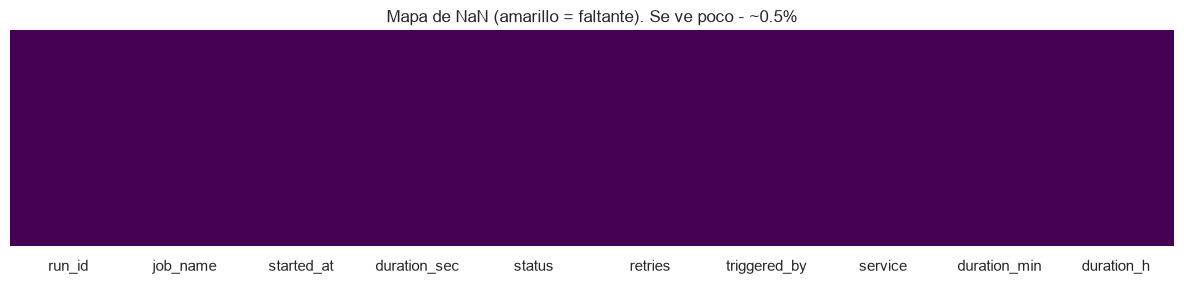

In [2]:
# Detectar NaN
fig, ax = plt.subplots(figsize=(12, 3))
sns.heatmap(runs.isnull(), cbar=False, yticklabels=False, cmap='viridis', ax=ax)
ax.set_title('Mapa de NaN (amarillo = faltante). Se ve poco - ~0.5%')
plt.tight_layout()
plt.savefig('../html/lab2_fig1_nan.png', dpi=110, bbox_inches='tight')
plt.show()

In [3]:
# Detectar y mostrar duraciones imposibles
impossible = (runs['duration_sec'] < 0) | (runs['duration_sec'] > 86400)
print(f'Duraciones imposibles: {impossible.sum()} de {len(runs)}')
print('Ejemplos de datos imposibles (los borraremos):')
print(runs[impossible][['run_id','job_name','duration_sec','status']].head())

# Limpiar
runs = runs.loc[~impossible].copy()
med_by_job = runs.groupby('job_name')['duration_sec'].transform('median')
runs['duration_sec'] = runs['duration_sec'].fillna(med_by_job)
runs['job_name'] = runs['job_name'].fillna(runs['job_name'].mode().iloc[0])
# Regenerar columnas humanas
runs['duration_min'] = runs['duration_sec'] / 60
runs['duration_h'] = runs['duration_sec'] / 3600
print(f'\nDespues de limpieza: {len(runs)} runs validos')

Duraciones imposibles: 16 de 1500
Ejemplos de datos imposibles (los borraremos):
      run_id          job_name  duration_sec   status
196  R-00197  scale_deployment         -10.0  success
305  R-00306    rotate_secrets       86401.0  success
320  R-00321    rotate_secrets       86401.0  success
461  R-00462  scale_deployment      100000.0  success
552  R-00553      cert_renewal         -10.0  success

Despues de limpieza: 1484 runs validos


## 3. Distribucion horaria - cuando corren los jobs?

Antes de mirar rendimiento, veamos el ritmo. Esto te dice si tienes picos de carga (batch nocturno) o distribucion uniforme.

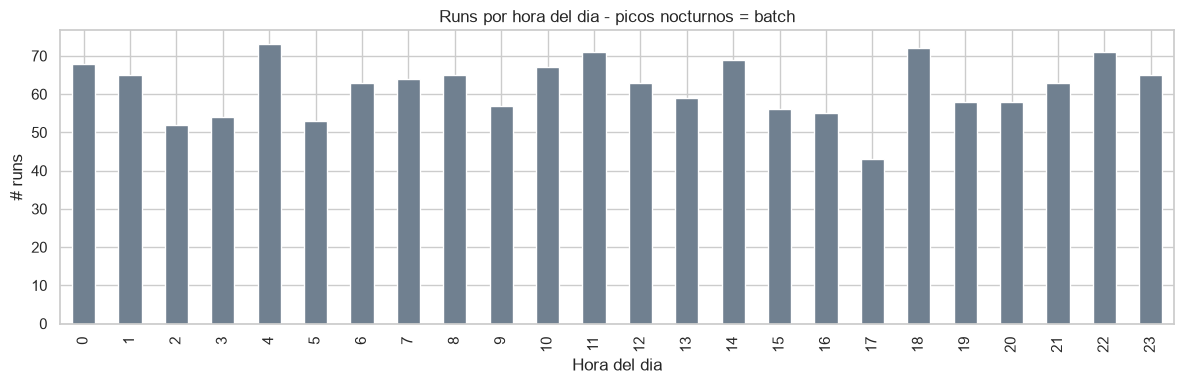

In [4]:
runs['hour'] = runs['started_at'].dt.hour
fig, ax = plt.subplots(figsize=(12, 4))
runs.groupby('hour').size().plot(kind='bar', color='slategray', ax=ax)
ax.set_title('Runs por hora del dia - picos nocturnos = batch')
ax.set_xlabel('Hora del dia')
ax.set_ylabel('# runs')
plt.tight_layout()
plt.savefig('../html/lab2_fig2_hourly.png', dpi=110, bbox_inches='tight')
plt.show()

## 4. Boxplot por job - entendiendo los outliers

**Por que usamos boxplot?** Resume una distribucion en 5 numeros clave:
- **Min / Max** (los bigotes): lo normal, sin outliers
- **Caja (Q1-Q3)**: el 50% tipico de tus runs
- **Rayita central**: la mediana
- **Puntos arriba del bigote**: outliers = runs anormales (lentos)

**Por que escala log?** Hay jobs de 3 segundos (purge_cache) y de 30 minutos (db_vacuum). En escala lineal, los pequeños se aplastan contra cero y no ves nada. La escala log te deja comparar extremos sin perder detalle.

**Que decision tomamos?** Si los outliers arriba son picos recurrentes = incidente real (investigar). Si son anomalías raras = bug del exporter (filtrar). En este lab los outliers son jobs lentos legítimos (5% del data artificialmente pesado).

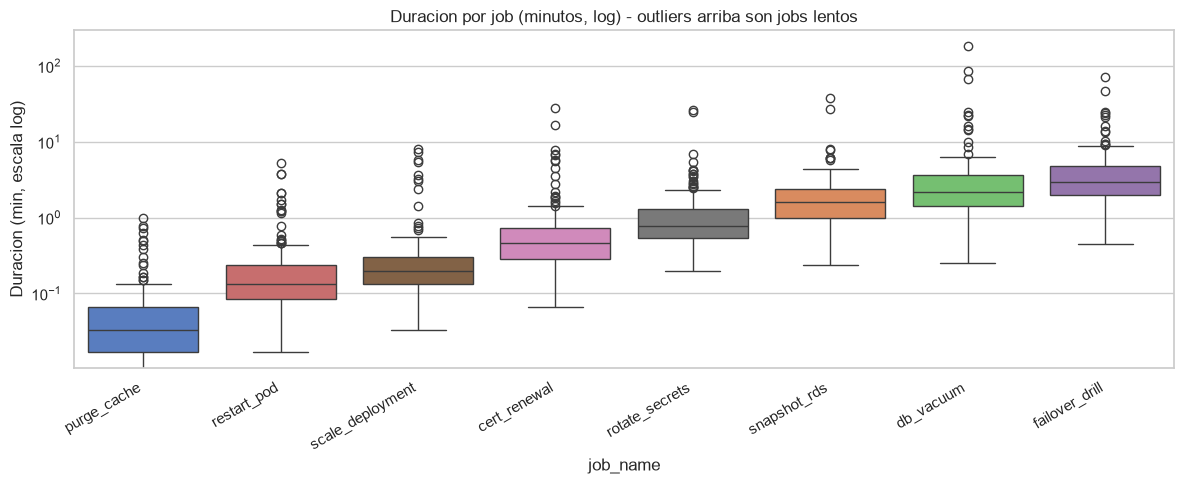

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
order = runs.groupby('job_name')['duration_min'].median().sort_values().index
sns.boxplot(data=runs, x='job_name', y='duration_min', order=order, hue='job_name', legend=False, ax=ax)
ax.set_yscale('log')
ax.set_title('Duracion por job (minutos, log) - outliers arriba son jobs lentos')
ax.set_ylabel('Duracion (min, escala log)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../html/lab2_fig3_boxplot.png', dpi=110, bbox_inches='tight')
plt.show()

## 5. Tabla por job - horas-hombre perdidas y decision

**Como se calcula el costo humano**:
1. `failure_rate` = proporcion de runs que fallan
2. `failures_per_year` = failure_rate * runs_dia * 365
3. `hours_lost_per_year` = failures_per_year * MTTR_seg / 3600

**Tu recomendacion**:
- **Alta falla + alto MTTR** = reescribir (causa dolores repetidos y largos)
- **Alta falla + bajo MTTR** = optimizar script (falla rapido, posiblemente logica mal)
- **Baja falla + alto MTTR** = reescribir solo cuando falla (es lento al fallar)
- **Baja falla + bajo MTTR** = mantener (esta bien)

In [6]:
by_job = runs.groupby('job_name').agg(
    runs=('run_id', 'count'),
    success_rate=('status', lambda s: (s == 'success').mean()),
    avg_retries=('retries', 'mean'),
    p50_dur_min=('duration_min', lambda s: s.quantile(0.5)),
    p95_dur_min=('duration_min', lambda s: s.quantile(0.95)),
    failure_rate=('status', lambda s: (s != 'success').mean()),
)
failed = runs[runs['status'].isin(['failed', 'timeout'])]
by_job['mttr_min'] = failed.groupby('job_name')['duration_min'].median()
by_job = by_job.fillna(0).round(3)
# Estimaciones anuales (asumimos ~30 dias de datos)
by_job['failures_per_year'] = (by_job['failure_rate'] * by_job['runs'] * 365 / 30).round(0)
by_job['hours_lost_per_year'] = (by_job['failures_per_year'] * by_job['mttr_min'] / 60).round(1)
# Decision sugerida
def suggestion(r):
    if r['failure_rate'] >= 0.10 and r['mttr_min'] >= 5:
        return 'REESCRIBIR'
    if r['failure_rate'] >= 0.07 and r['mttr_min'] < 5:
        return 'OPTIMIZAR'
    if r['failure_rate'] < 0.07 and r['mttr_min'] >= 5:
        return 'REESCRIBIR SI FALLA'
    return 'MANTENER'
by_job['decision'] = by_job.apply(suggestion, axis=1)
by_job.sort_values('hours_lost_per_year', ascending=False)

,runs,success_rate,avg_retries,p50_dur_min,p95_dur_min,failure_rate,mttr_min,failures_per_year,hours_lost_per_year,decision
job_name,,,,,,,,,,
failover_drill,191,0.770,0.466,2.900,9.708,0.230,3.158,534.0,28.1,OPTIMIZAR
db_vacuum,187,0.775,0.433,2.183,9.373,0.225,2.358,512.0,20.1,OPTIMIZAR
snapshot_rds,175,0.880,0.223,1.600,4.335,0.120,1.867,256.0,8.0,OPTIMIZAR
rotate_secrets,179,0.911,0.168,0.783,3.507,0.089,1.058,194.0,3.4,OPTIMIZAR
cert_renewal,194,0.933,0.149,0.462,2.387,0.067,0.483,158.0,1.3,MANTENER
scale_deployment,191,0.927,0.120,0.200,0.808,0.073,0.275,170.0,0.8,OPTIMIZAR
restart_pod,181,0.923,0.155,0.133,1.217,0.077,0.183,170.0,0.5,OPTIMIZAR
purge_cache,186,0.946,0.113,0.033,0.246,0.054,0.075,122.0,0.2,MANTENER


## 6. Visualizacion - que job duele mas al equipo

Las barras **rojas** son los jobs prioritarios para reescribir (>5 horas-hombre perdidas al año).

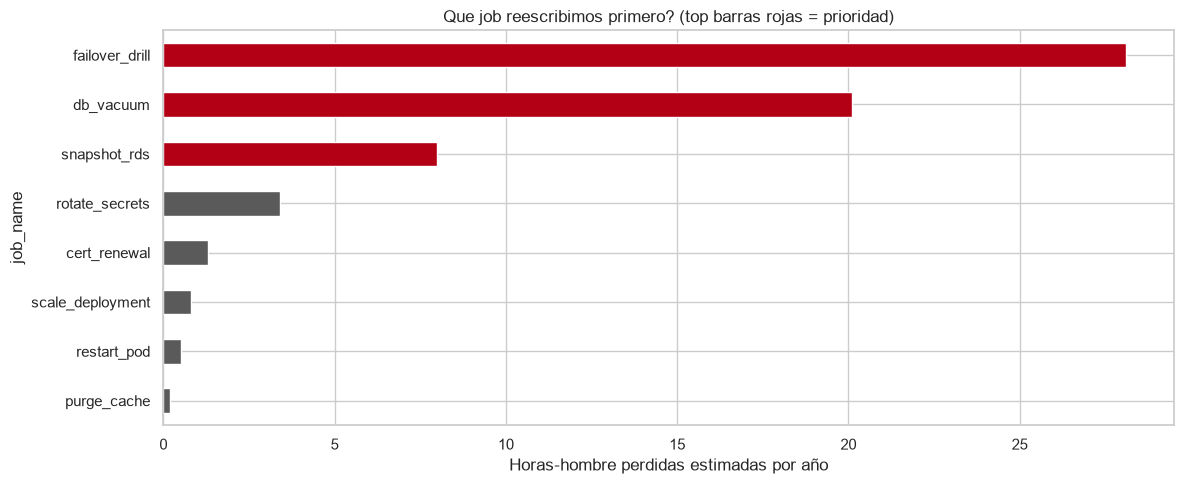

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
top_loss = by_job.sort_values('hours_lost_per_year', ascending=True)
colors = ['#b30015' if x > 5 else '#5a5a5a' for x in top_loss['hours_lost_per_year']]
top_loss['hours_lost_per_year'].plot(kind='barh', color=colors, ax=ax)
ax.set_xlabel('Horas-hombre perdidas estimadas por año')
ax.set_title('Que job reescribimos primero? (top barras rojas = prioridad)')
plt.tight_layout()
plt.savefig('../html/lab2_fig4_hours_lost.png', dpi=110, bbox_inches='tight')
plt.show()

## 7. Cuadrante MTTR vs tasa de fallo - decision visual

Mirando el scatter: el cuadrante **superior-izquierdo** (baja falla + alto MTTR) es el **peor**: falla poco pero cuando falla, tarda mucho. Eso es un job mal diseñado. El cuadrante **inferior-derecho** (alta falla + bajo MTTR) falla mucho pero rapido: posiblemente script con logica mala que tira excepcion.

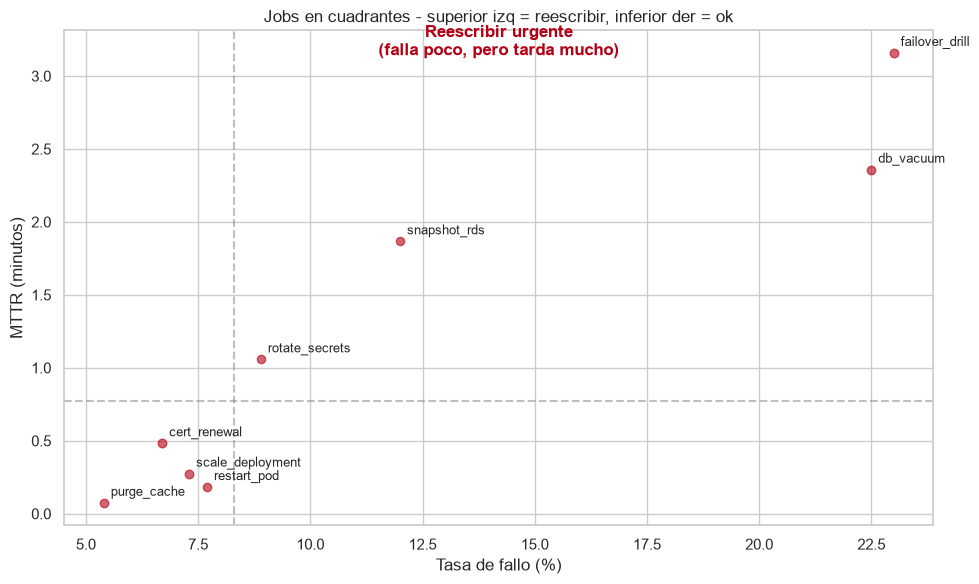

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
for _, row in by_job.iterrows():
    ax.scatter(row['failure_rate'] * 100, row['mttr_min'], s=row['runs']/5, alpha=0.6, color='#b30015')
    ax.annotate(row.name, (row['failure_rate'] * 100, row['mttr_min']),
                xytext=(5, 5), textcoords='offset points', fontsize=9)
ax.axhline(y=by_job['mttr_min'].median(), color='grey', linestyle='--', alpha=0.5)
ax.axvline(x=by_job['failure_rate'].median() * 100, color='grey', linestyle='--', alpha=0.5)
ax.set_xlabel('Tasa de fallo (%)')
ax.set_ylabel('MTTR (minutos)')
ax.set_title('Jobs en cuadrantes - superior izq = reescribir, inferior der = ok')
ax.text(0.5, 0.95, 'Reescribir urgente\n(falla poco, pero tarda mucho)',
        transform=ax.transAxes, ha='center', color='#b30015', fontweight='bold')
plt.tight_layout()
plt.savefig('../html/lab2_fig5_quadrant.png', dpi=110, bbox_inches='tight')
plt.show()

## 8. Tu decision como SRE

Con los datos de la tabla anterior:

- **#1 candidato a reescribir**: el job con la **mayor `hours_lost_per_year`** y decision sugerida **REESCRIBIR**. Reescribirlo elimina el mayor dolor humano.
- **#1 candidato a optimizar**: el job con `failure_rate >= 7%` y `decision = OPTIMIZAR`. Suele ser un script con logica fragil.
- **#1 candidato a dar de baja**: el job con menos `runs` y `failure_rate = 0`. Si nadie lo corre, se puede eliminar.

Muestra tu tabla al facilitador y argumenta tu eleccion con estos 3 numeros.

---

**Frase ejecutiva para tu reporte** (1 linea):
> «Reescribir [JOB] ahorra ~X horas/año a [EQUIPO]; el script se reescribe en ~Y sprints; dejamos de gastar Z retries/semana.»